# 🔬 Laboratorio EDA: statsbomb_Serie_A_2015_2016_match_3879664.csv
Esegui le celle per esplorare i dati. Modifica i parametri a tuo piacimento.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import sys
sys.path.append('../') # Permette di leggere la cartella scripts
from scripts.db_uploader import upload_to_postgres

df = pd.read_csv('../data/raw/statsbomb_Serie_A_2015_2016_match_3879664.csv', low_memory=False)
print(f'Dataset caricato: {df.shape[0]} righe e {df.shape[1]} colonne')
df.head(3)

Dataset caricato: 3406 righe e 93 colonne


,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_right_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4141, 'lineup': [{'player': {'id...",Sampdoria,234,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 442, 'lineup': [{'player': {'id'...",Palermo,2256,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Sampdoria,234,00:00:00.000,Half Start,NaN


In [2]:
# 1. ESPLORAZIONE BASE
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 93 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ball_receipt_outcome            204 non-null    str    
 1   ball_recovery_offensive         1 non-null      object 
 2   ball_recovery_recovery_failure  8 non-null      object 
 3   block_offensive                 1 non-null      object 
 4   carry_end_location              713 non-null    str    
 5   clearance_aerial_won            9 non-null      object 
 6   clearance_body_part             56 non-null     str    
 7   clearance_head                  29 non-null     object 
 8   clearance_left_foot             6 non-null      object 
 9   clearance_right_foot            21 non-null     object 
 10  counterpress                    96 non-null     object 
 11  dribble_nutmeg                  3 non-null      object 
 12  dribble_outcome                 27 non-null  

In [3]:
# 2. CODIFICA VARIABILI CATEGORICHE (Label Encoding)
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')
    df[col+'_encoded'] = LabelEncoder().fit_transform(df[col].astype(str))
print('Codifica completata.')

C:\Users\salva\AppData\Local\Temp\ipykernel_7916\3258307465.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()


Codifica completata.


C:\Users\salva\AppData\Local\Temp\ipykernel_7916\3258307465.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+'_encoded'] = LabelEncoder().fit_transform(df[col].astype(str))
C:\Users\salva\AppData\Local\Temp\ipykernel_7916\3258307465.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+'_encoded'] = LabelEncoder().fit_transform(df[col].astype(str))
C:\Users\salva\AppData\Local\Temp\ipykernel_7916\3258307465.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.inse

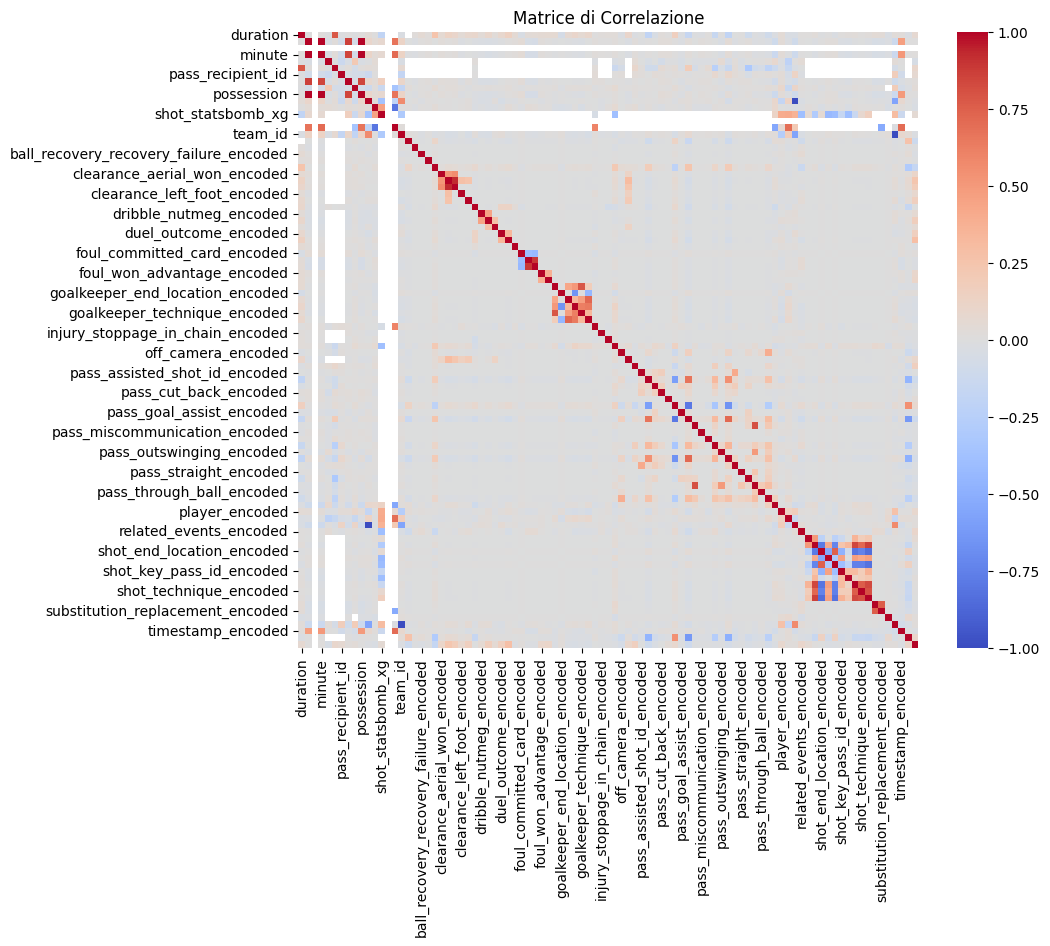

In [4]:
# 3. MATRICE DI CORRELAZIONE
numerical_data = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_data.corr(), annot=False, cmap='coolwarm')
plt.title('Matrice di Correlazione')
plt.show()

## 🚀 FINE EDA: CARICAMENTO SU DATABASE
Quando hai finito la pulizia, esegui la cella qui sotto per inviare il Dataset Pulito a PostgreSQL (DBeaver).

In [5]:
# Assicurati di aver impostato la password corretta in scripts/db_uploader.py
upload_to_postgres(df, table_name='statsbomb_serie_a_2015_2016_match_3879664_clean')

⏳ Connessione a PostgreSQL per creare la tabella 'statsbomb_serie_a_2015_2016_match_3879664_clean'...
✅ SUCCESSO! 3406 righe caricate in modo sicuro nella tabella SQL 'statsbomb_serie_a_2015_2016_match_3879664_clean'.
